In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
import cv2
import os

def resize_image(image_path, target_size=(150, 150)):
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, target_size)
    return image_resized

In [6]:
def normalize_image(image):
    return image / 255.0

In [7]:
def histogram_equalization(image):
    image_yuv = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
    image_yuv[:, :, 0] = cv2.equalizeHist(image_yuv[:, :, 0])
    image_equalized = cv2.cvtColor(image_yuv, cv2.COLOR_YUV2BGR)
    return image_equalized

In [8]:
def denoise_image(image):
    return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

In [9]:
import random
def augment_image(image):
    # Random flip
    if random.random() > 0.5:
        image = cv2.flip(image, 1)  
    return image

In [10]:
def convert_to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [13]:
import cv2
import os
from PIL import Image
import numpy as np

def resize_image(image_path, target_size=(150, 150)):
    print(f"Processing image: {image_path}")
    
    try:
        pil_image = Image.open(image_path).convert('RGB')
        image = np.array(pil_image)

        if image.dtype == 'float64':
            image = (image * 255).astype('uint8')
        
        image_resized = cv2.resize(image, target_size)
        return image_resized
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def is_image_file(file_name):
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    return any(file_name.lower().endswith(ext) for ext in image_extensions)

base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_scc'
preprocessed_images = []

for file_name in os.listdir(base_dir):
    if not is_image_file(file_name):
        print(f"Skipping non-image file: {file_name}")
        continue
    
    image_path = os.path.join(base_dir, file_name)
    preprocessed_image = resize_image(image_path)
    
    if preprocessed_image is not None:
        preprocessed_images.append(preprocessed_image)


Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc10.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc100.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1000.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1001.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1002.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1003.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1004.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1005.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1006.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1007.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lun

In [14]:
import numpy as np

# Assuming preprocessed_images is the list of all resized images
preprocessed_images = np.array(preprocessed_images)
print(f"Total preprocessed images: {len(preprocessed_images)}")

Total preprocessed images: 5000


In [15]:
labels = []

# Assign labels corresponding to the lung cancer types
for i in range(len(os.listdir(base_dir))):
    labels.append(0)  # Assuming 0 for 'lung_scc', 1 for 'lung_n', 2 for 'lung_aca'

In [16]:
labels = np.array(labels)
print(f"Labels shape: {labels.shape}")

Labels shape: (5000,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(preprocessed_images, labels, test_size=0.2, random_state=42)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [19]:
# Define CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes for the 3 types of lung cancer
])

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [21]:
# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 384ms/step - accuracy: 1.0000 - loss: 1.3061e-10 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 372ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 89s 426ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 404ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 399ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 370ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 347ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
125/125 ━━━━━━━━

In [24]:
def predict_image(image_path):
    image = resize_image(image_path)  
    image = np.expand_dims(image, axis=0)  
    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)
    return predicted_class

image_path = "C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_n\\lungn999.jpeg"
predicted_class = predict_image(image_path)
print(f"Predicted class: {predicted_class}")

Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_n\lungn999.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted class: 0


SVC

In [25]:
from skimage.feature import hog
from skimage.io import imread
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os
import numpy as np

In [26]:
# HOG feature extraction function
def extract_hog_features(image_path):
    image = imread(image_path)
    features, hog_image = hog(image, block_norm='L2-Hys', pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True, channel_axis=-1)  # channel_axis replaces multichannel
    return features

In [27]:
# Directories for each class
class_mapping = {
    'lung_scc': 0,   # Label for squamous cell carcinoma
    'lung_n': 1,     # Label for normal lung tissue
    'lung_aca': 2    # Label for adenocarcinoma
}

data = []
labels = []

base_dir = "C:\\Users\\pidik\\Downloads\\lung_image_sets"

In [29]:
def extract_hog_features(image_path):
    image = imread(image_path)
    image = cv2.resize(image, (150, 150))  # Resize to 150x150 or any smaller size
    features, hog_image = hog(image, block_norm='L2-Hys', pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True, channel_axis=-1)
    return features

In [31]:
import concurrent.futures

def process_image(image_path, class_label):
    hog_features = extract_hog_features(image_path)
    return hog_features, class_label

data = []
labels = []

with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = []
    for class_name, class_label in class_mapping.items():
        class_dir = os.path.join(base_dir, class_name)
        if os.path.exists(class_dir):
            for file_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, file_name)
                futures.append(executor.submit(process_image, image_path, class_label))
    
    for future in concurrent.futures.as_completed(futures):
        hog_features, class_label = future.result()
        data.append(hog_features)
        labels.append(class_label)

In [33]:
# Convert data and labels to numpy arrays
data = np.array(data)
labels = np.array(labels)

In [34]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [35]:
# Train an SVM classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [36]:
# Predict on the test set
y_pred = svm_classifier.predict(X_test)

In [39]:
# Evaluate the SVM model
accuracy = accuracy_score(y_test, y_pred)
print(f"SVC accuracy: {accuracy * 100:.2f}%")

SVC accuracy: 76.27%


In [40]:
import os
import cv2
import numpy as np
from PIL import Image

def resize_image(image_path, target_size=(150, 150)):
    print(f"Processing image: {image_path}")
    
    try:
        # Use PIL to open the image and ensure it's in RGB format
        pil_image = Image.open(image_path).convert('RGB')
        image = np.array(pil_image)

        # Convert to 8-bit if needed
        if image.dtype == 'float64':
            image = (image * 255).astype('uint8')
        
        image_resized = cv2.resize(image, target_size)
        return image_resized
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def is_image_file(file_name):
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    return any(file_name.lower().endswith(ext) for ext in image_extensions)

# Define base directory and class mapping
base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'
class_mapping = {
    'lung_scc': 0,
    'lung_n': 1,
    'lung_aca': 2
}

# Load and preprocess images for all classes
images = []
labels = []

for class_name, class_label in class_mapping.items():
    class_dir = os.path.join(base_dir, class_name)
    if os.path.exists(class_dir):
        for file_name in os.listdir(class_dir):
            if is_image_file(file_name):
                image_path = os.path.join(class_dir, file_name)
                preprocessed_image = resize_image(image_path)
                
                if preprocessed_image is not None:
                    images.append(preprocessed_image)
                    labels.append(class_label)

# Convert to numpy arrays
images = np.array(images, dtype='float32') / 255.0  # Normalize pixel values
labels = np.array(labels)

Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc10.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc100.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1000.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1001.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1002.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1003.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1004.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1005.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1006.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc1007.jpeg
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lun

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up your ImageDataGenerator for testing
test_datagen = ImageDataGenerator(rescale=1./255)

# Create a test generator
test_generator = test_datagen.flow_from_directory(
    'C:\\Users\\pidik\\Downloads\\test_lung',  # Change this path as needed
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',  # Use categorical if you have multiple classes
    shuffle=False  # Don't shuffle for evaluation
)

train_generator = train_datagen.flow_from_directory(
    'C:\\Users\\pidik\\Downloads\\train_lung', 
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)pil

# Getting the true labels from the generator
test_labels = test_generator.classes

Found 3000 images belonging to 3 classes.


CNN

In [54]:
# Check model summary to ensure it's configured correctly
model.summary()

# Generate predictions for multiple images and see the probabilities
for image_path in ["C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_aca\\lungaca981.jpeg",
                   "C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_n\\lungn999.jpeg",
                   "C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_scc\\lungscc998.jpeg"]:
    predicted_class = predict_image(image_path)
    prediction_probs = model.predict(np.expand_dims(resize_image(image_path), axis=0))
    print(f"Predicted class: {predicted_class}, Probabilities: {prediction_probs}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,910,219 (121.73 MB)

 Trainable params: 10,636,739 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,273,480 (81.15 MB)

Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_aca\lungaca981.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_aca\lungaca981.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted class: lung_scc, Probabilities: [[1. 0. 0.]]
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_n\lungn999.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_n\lungn999.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted class: lung_scc, Probabilities: [[1. 0. 0.]]
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc998.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc998.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted class: lung_scc, Probabilities: [[1. 0. 0.]]


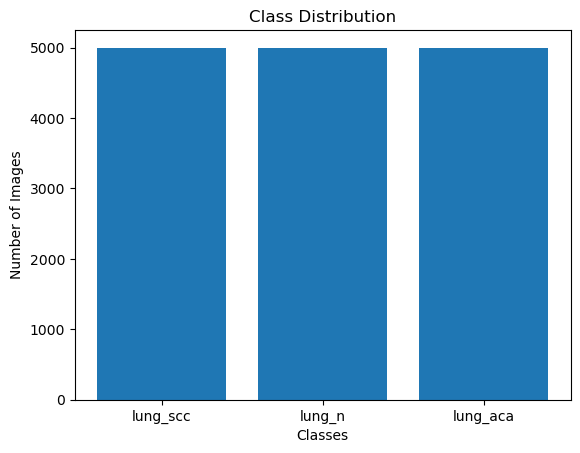

In [55]:
import os
import matplotlib.pyplot as plt

base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'
classes = ['lung_scc', 'lung_n', 'lung_aca']
counts = []

for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    counts.append(len(os.listdir(class_dir)))

plt.bar(classes, counts)
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.show()

In [63]:
import os

def get_true_label_from_path(img_path):
    """Extract the true label from the image path."""
    # Get the parent directory name (class name)
    class_name = os.path.basename(os.path.dirname(img_path))
    
    # Define a mapping from class names to numerical labels if needed
    class_mapping = {
        'lung_scc': 0,
        'lung_n': 1,
        'lung_aca': 2
    }
    
    # Return the class name or corresponding label
    return class_mapping.get(class_name, class_name)  # Return class name if not in mapping

In [65]:
import numpy as np

# Predict on a few images
        
sample_images = ['C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_scc\\lungscc998.jpeg', 'C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_scc\\lungscc999.jpeg', 'C:\\Users\\pidik\\Downloads\\lung_image_sets\\lung_aca\\lungaca981.jpeg']  # Replace with actual image paths
for img_path in sample_images:
    predicted_class = predict_image(img_path)
    true_label = get_true_label_from_path(img_path) 
    print(f"Image: {img_path}, True: {true_label}")

Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc998.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc998.jpeg, True: 0
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc999.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Image: C:\Users\pidik\Downloads\lung_image_sets\lung_scc\lungscc999.jpeg, True: 0
Processing image: C:\Users\pidik\Downloads\lung_image_sets\lung_aca\lungaca981.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Image: C:\Users\pidik\Downloads\lung_image_sets\lung_aca\lungaca981.jpeg, True: 2


In [59]:
import os

def print_directory_structure(base_dir, indent=0):
    """Print the directory structure."""
    for item in os.listdir(base_dir):
        item_path = os.path.join(base_dir, item)
        print(' ' * indent + '- ' + item)  # Print the item with indentation
        if os.path.isdir(item_path):  # If it's a directory, call the function recursively
            print_directory_structure(item_path, indent + 4)

# Set your base directory here
base_directory = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'
print_directory_structure(base_directory)

- lung_aca
    - lungaca1.jpeg
    - lungaca10.jpeg
    - lungaca100.jpeg
    - lungaca1000.jpeg
    - lungaca1001.jpeg
    - lungaca1002.jpeg
    - lungaca1003.jpeg
    - lungaca1004.jpeg
    - lungaca1005.jpeg
    - lungaca1006.jpeg
    - lungaca1007.jpeg
    - lungaca1008.jpeg
    - lungaca1009.jpeg
    - lungaca101.jpeg
    - lungaca1010.jpeg
    - lungaca1011.jpeg
    - lungaca1012.jpeg
    - lungaca1013.jpeg
    - lungaca1014.jpeg
    - lungaca1015.jpeg
    - lungaca1016.jpeg
    - lungaca1017.jpeg
    - lungaca1018.jpeg
    - lungaca1019.jpeg
    - lungaca102.jpeg
    - lungaca1020.jpeg
    - lungaca1021.jpeg
    - lungaca1022.jpeg
    - lungaca1023.jpeg
    - lungaca1024.jpeg
    - lungaca1025.jpeg
    - lungaca1026.jpeg
    - lungaca1027.jpeg
    - lungaca1028.jpeg
    - lungaca1029.jpeg
    - lungaca103.jpeg
    - lungaca1030.jpeg
    - lungaca1031.jpeg
    - lungaca1032.jpeg
    - lungaca1033.jpeg
    - lungaca1034.jpeg
    - lungaca1035.jpeg
    - lungaca1036.jpeg
    - lun

In [60]:
def is_image_file(file_name):
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    return any(file_name.lower().endswith(ext) for ext in image_extensions)

for item in os.listdir(base_directory):
    item_path = os.path.join(base_directory, item)
    if os.path.isdir(item_path):
        print(f"Directory: {item}")
        for file_name in os.listdir(item_path):
            if is_image_file(file_name):
                print(f"  Image: {file_name}")
            else:
                print(f"  Non-image file: {file_name}")


Directory: lung_aca
  Image: lungaca1.jpeg
  Image: lungaca10.jpeg
  Image: lungaca100.jpeg
  Image: lungaca1000.jpeg
  Image: lungaca1001.jpeg
  Image: lungaca1002.jpeg
  Image: lungaca1003.jpeg
  Image: lungaca1004.jpeg
  Image: lungaca1005.jpeg
  Image: lungaca1006.jpeg
  Image: lungaca1007.jpeg
  Image: lungaca1008.jpeg
  Image: lungaca1009.jpeg
  Image: lungaca101.jpeg
  Image: lungaca1010.jpeg
  Image: lungaca1011.jpeg
  Image: lungaca1012.jpeg
  Image: lungaca1013.jpeg
  Image: lungaca1014.jpeg
  Image: lungaca1015.jpeg
  Image: lungaca1016.jpeg
  Image: lungaca1017.jpeg
  Image: lungaca1018.jpeg
  Image: lungaca1019.jpeg
  Image: lungaca102.jpeg
  Image: lungaca1020.jpeg
  Image: lungaca1021.jpeg
  Image: lungaca1022.jpeg
  Image: lungaca1023.jpeg
  Image: lungaca1024.jpeg
  Image: lungaca1025.jpeg
  Image: lungaca1026.jpeg
  Image: lungaca1027.jpeg
  Image: lungaca1028.jpeg
  Image: lungaca1029.jpeg
  Image: lungaca103.jpeg
  Image: lungaca1030.jpeg
  Image: lungaca1031.jpeg
 